# Unit - 5 Classification Models ~ 12 Marks
- Decision Tree
- KNN - K Nearest Neighbours 
- Random Forest
- SVM - Support Vector Machines
- Evaluation metrics

## Regression vs Classification
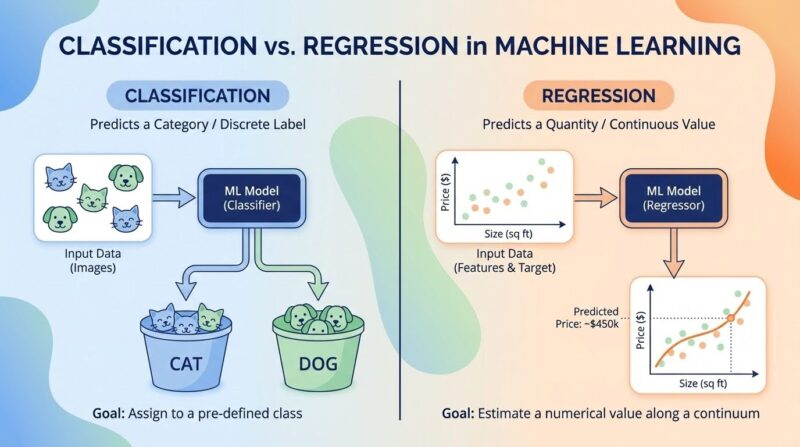

## Classification Models
- **Data:** Divided into predefined, discrete categories
- **Goal:** Assign an input to one of the categories
- **Model output:** A specific category from a set

## DECISION TREE ON JOB OFFER DATA

In [1]:
## IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,plot_tree


In [2]:
# Load dataset
data = pd.read_csv("job_offers.csv")

In [3]:
data.head(2)

,CGPA,Communication,Aptitude,ProgrammingSkill,JobOffered
0,2,1,1,1,1
1,1,1,1,1,1


In [4]:
# Define features and target
x = data.drop(columns=['JobOffered'])
y = data['JobOffered']
print(x.shape)
print(y.shape)

(20, 4)
(20,)


In [5]:
# Create model
dtree = DecisionTreeClassifier(criterion='entropy',max_depth=3)

In [7]:
# Fit the model
dtree.fit(x,y)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
# Predict based on model
predictions= dtree.predict(x)

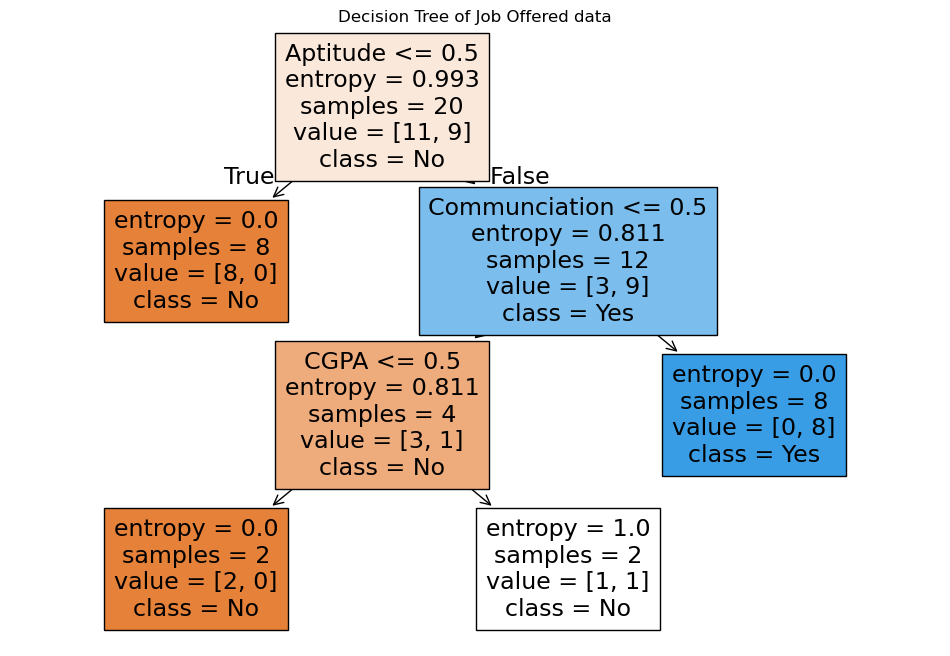

In [9]:
# PLOT THE DECISION TREE (OPTIONAL)
plt.figure(figsize=(12,8))
plot_tree(dtree,filled=True,
         feature_names=['CGPA','Communciation','Aptitude','Programming Skill'],
         class_names=['No','Yes'])
plt.title("Decision Tree of Job Offered data")
plt.show()

## EVALUATION METRICS
- Confusion matrix
- accuracy score
- precision score
- recall score
- f1 score
- classification report

In [11]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,classification_report

## GENERATE CONFUSION MATRIX

In [13]:
cm = confusion_matrix(y,predictions)
print("Confusion Matrix = \n",cm)

Confusion Matrix = 
 [[11  0]
 [ 1  8]]


## EXTRACT TN,FP,FN,TP

In [15]:
TN,FP,FN,TP = cm.ravel()
print(f"True Negatives are ", TN)
print(f"False Positives are ", FP)
print(f"False Negatives are ", FN)
print(f"True Positives are ", TP)
print(cm)

True Negatives are  11
False Positives are  0
False Negatives are  1
True Positives are  8
[[11  0]
 [ 1  8]]


## Accuracy score
- accuracy = (TP + TN) / (TP + TN + FP + FN)

In [18]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
print(accuracy)

0.95


## Precision score
- precision = TP / (TP+FP) 

In [19]:
precision = TP / (TP+FP) 
print(precision)

1.0


## Recall
- recall = TP / (TP + FN)

In [20]:
recall = TP / (TP + FN)
print(recall)

0.8888888888888888


## f1 score
- f1 = 2 * (precision*recall)/ (precision+recall)

In [21]:
f1 = 2 * (precision*recall)/ (precision+recall)
print(f1)

0.9411764705882353


## PRINT CLASSIFICATION REPORT

In [22]:
print(classification_report(y,predictions))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      0.89      0.94         9

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



## KNN (K NEAREST ALGORITHM)
**ALGORITHM STEPS**
1. Determine parameter k
2. Calculate distance between query and features
3. Sort distance of nearest neighbors and find minimum distance neighbors
4. Gather category of nearest neighbors
5. Using voting, find the category of the query

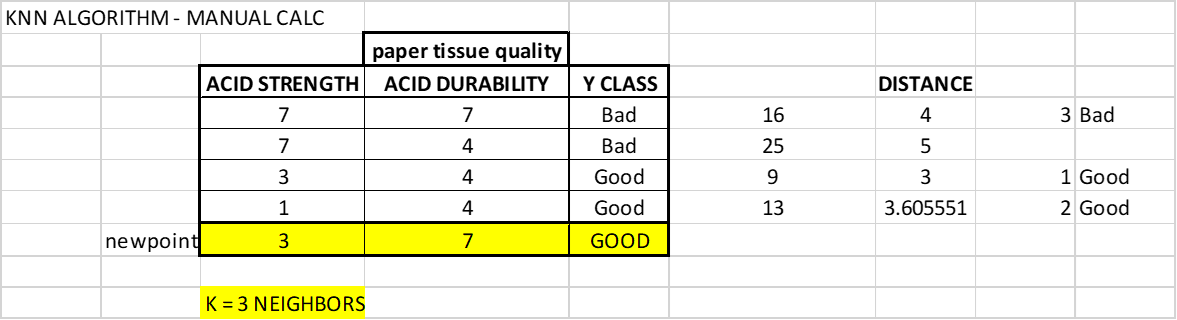

## PYTHON IMPLEMENTATION OF KNN

In [1]:
## IMPORT LIBRARIES
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
## features and target
x = np.array([[7,7],[7,4],[3,4],[1,4]])
y = np.array([-1,-1,1,1])
print(x.shape)
print(y.shape)

(4, 2)
(4,)


In [3]:
## create model
knn = KNeighborsClassifier(n_neighbors=3)

In [4]:
knn.fit(x,y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [6]:
## Model prediction
knn.predict([[3,7]])

array([1])

## TEMPLATE PROGRAM FOR KNN

## PB 267 
```
You are tasked with using the k-Nearest Neighbors (kNN) algorithm to classify whether patients have diabetes or not based on 
certain diagnostic measurements. You have been provided with diabetes.csv file. The datasets consist of several medical 
predictor (independent) variables and one target (dependent) variable, Outcome. Independent variables include the number of 
pregnancies the patient has had, their BMI, insulin level, age, and so on. Also perform Model Performance Analysis using 
confusion matrix. Training - 75% and random state 42, neighbors = 5
```

In [7]:
## import libraries
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score

In [8]:
## Load dataset
df = pd.read_csv("diabetes.csv")
df.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


In [10]:
## Feature and target
x = df.drop(columns=['Outcome'])
y = df['Outcome']

In [11]:
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [12]:
## split the data
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.25,random_state=42
)

In [14]:
## Create model
knn =KNeighborsClassifier(n_neighbors=5)

In [15]:
## Fit the model
knn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
## prediction
prediction = knn.predict(x_test)

In [19]:
## Accuracy and confusion matrix
print(accuracy_score(y_test,prediction))

0.65625


In [20]:
confusion_matrix(y_test,prediction)

array([[88, 35],
       [31, 38]])

### predict for the person who is 45 years old and does not take insulin
- Pregnancies - 1	
- Glucose	- 200
- BloodPressure - 180	
- SkinThickness - 30	
- BMI	- 30
- DiabetesPedigreeFunction - 0.245


In [21]:
# Pregnancies	
# Glucose	
# BloodPressure	
# SkinThickness	
# Insulin	
# BMI	
# DiabetesPedigreeFunction	
# Age	
# Outcome
knn.predict([[1,200,180,30,0,30,0.245,45]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([1])

## SUPPORT VECTOR MACHINES (SVM)
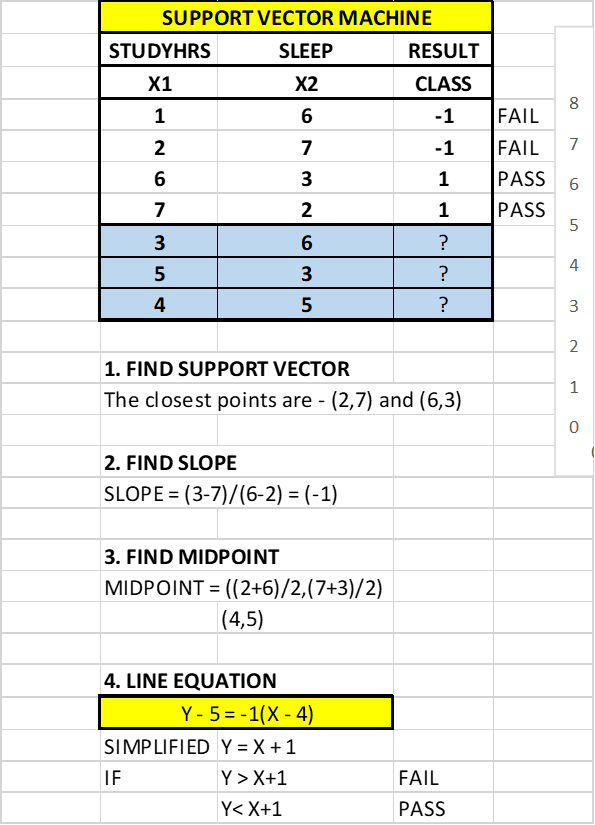

### PYTHON IMPLEMENTATION OF SUPPORT VECTOR MACHINE

Weight/slope is  [ 0.25 -0.25]
Intercept/Bias is  0.25


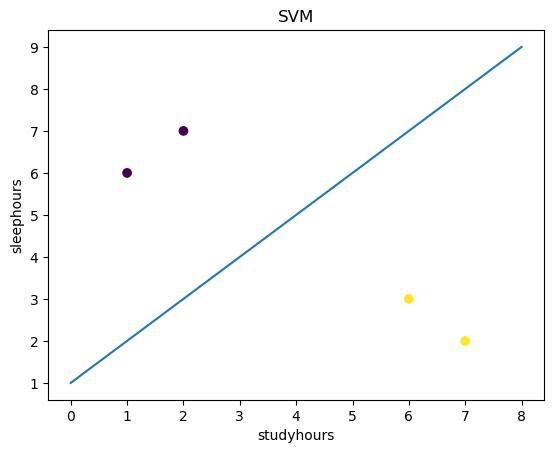

[-1  1  1]


In [6]:
import numpy as np
from sklearn.svm import SVC

## Define features and target
x  = np.array([[1,6],[2,7],[6,3],[7,2]])
y = np.array([-1,-1,1,1]) # -1 means fail and 1 means pass
## Create model
model = SVC(kernel='linear')
## fit the model
model.fit(x,y)
# print intercept and slope
w = model.coef_[0]
b = model.intercept_[0]
print("Weight/slope is ",w)
print("Intercept/Bias is ",b)

import matplotlib.pyplot as plt
plt.scatter(x[:,0],x[:,1],c=y)
xval = np.linspace(0,8,100)
yval = -(w[0]*xval + b)/w[1]
plt.plot(xval,yval)
plt.xlabel('studyhours')
plt.ylabel('sleephours')
plt.title("SVM")
plt.show()

# new points 
newpoints = np.array([[3,6],[5,3],[4,5]])
print(model.predict(newpoints))

### MANUAL CALCULATION CONFUSION MATRIX AND METRICS ~ 4 mcqs
#### AND RANDOM FOREST 

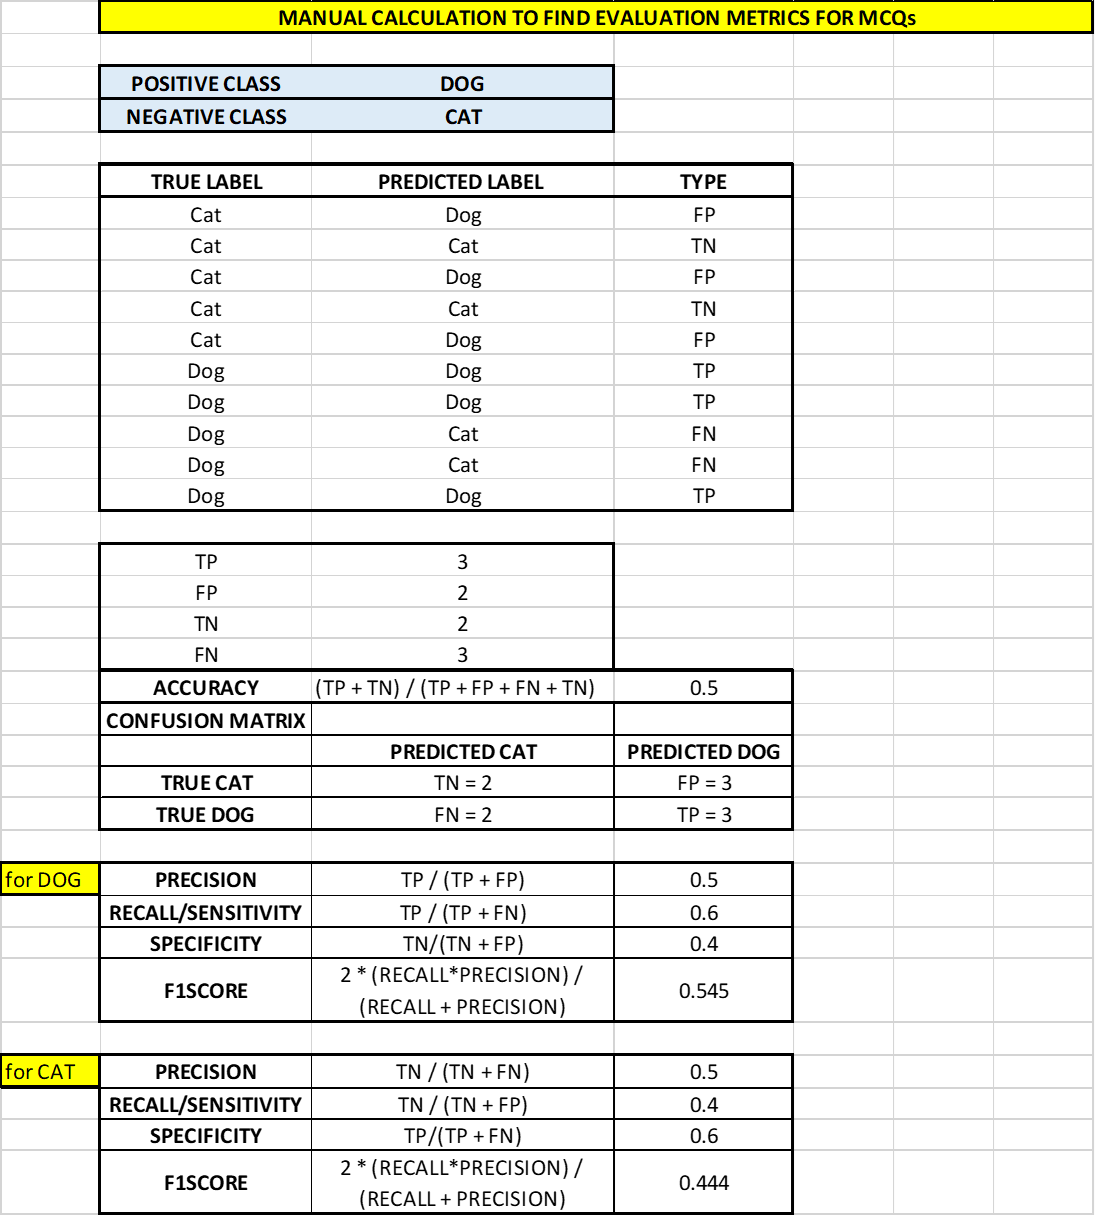

## RANDOM FOREST CLASSIFICATION ALGORITHM IN MACHINE LEARNING
- It is based on concept of bagging (Bootstrap Aggregating)
- Bootstrap aggregating means sampling with replacement and finally predicting the class based on the majority voting
- It is based on use of multiple decision trees to predict the category of the class

In [3]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
x = np.array([[1,6],[2,7],[6,3],[7,2]])
y = np.array([0,0,1,1]) # 0 means fail and 1 means pass
# create model
rf = RandomForestClassifier(
    n_estimators= 10, # No of trees
    max_depth=2,
    random_state=42
)
# Fit the model
rf.fit(x,y)
# new points 
newpoints = np.array([[3,6],[5,3],[4,5]])
print(rf.predict(newpoints))

[0 1 1]


## PB 313 Random Forest Classifier Implementation
```
Write Python code to implement a Random Forest Classifier using the following instructions:
Initialize the classifier with:
n_estimators = 100
random_state = 42
Train the model using training data.
Predict class labels for test data.
Evaluate the model by calculating:
Confusion Matrix
Accuracy score
```

In [ ]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score
## Assuming dataset is loaded and x features and y target is defined
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)
# Create model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
# Fit model
rf.fit(x_train,y_train)
# Prediction
y_pred = rf.predict(x_test)
# Confusion matrix and accuracy score
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
